
#  Optimisation par Algorithme Génétique : Le Miel et les Abeilles

Ce notebook illustre l'application d'un algorithme génétique pour résoudre un problème de type **Voyageur de Commerce (TSP)**, 
en simulant une ruche d'abeilles ouvrières qui cherchent à optimiser leur trajet entre les fleurs et la ruche.

Nous allons :  
- Implémenter la ruche et les abeilles (classe `Beehive`).  
- Visualiser l’évolution du meilleur chemin.  
- Comparer différentes stratégies : **mutation, fitness, sélection, crossover**.  
- Analyser les résultats obtenus.


In [29]:
import math
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import random, numpy as np
from graphviz import Digraph

In [30]:
class Bee:
    _id_counter = 0

    def __init__(self, path=None, parents=None, is_queen=False, id=None):
        if id is None:
            self.id = Bee._id_counter
            Bee._id_counter += 1
        else:
            self.id = id
        self.path = path[:] if path is not None else []
        self.parents = parents
        self.fitness = None
        self.distance = None
        self.is_queen = is_queen

    def evaluate(self, hive_position, fitness_mode="inverse", alpha=0.01, reference=None, max_distance=None):
        """Calcule la distance du parcours et la fitness selon le mode choisi."""
        if self.is_queen:
            self.distance = 0
            self.fitness = 0
            return self.fitness

        # Calcul unique de la distance totale
        dist = 0
        current = hive_position
        for flower in self.path:
            dist += math.dist(current, flower)
            current = flower
        dist += math.dist(current, hive_position)
        self.distance = dist

        # Calcul de la fitness
        if fitness_mode == "inverse":
            self.fitness = 1.0 / (dist + 1e-9)
        elif fitness_mode == "normalized":
            if max_distance:
                self.fitness = max(0.0, (max_distance - dist) / max_distance)
            else:
                self.fitness = 0.0
        elif fitness_mode == "exp":
            self.fitness = math.exp(-alpha * dist)
        elif fitness_mode == "ratio":
            if reference:
                self.fitness = reference / dist
            else:
                self.fitness = 0.0
        else:
            self.fitness = 1.0 / (dist + 1e-9)

        return self.fitness


class Beehive:
    def __init__(self, flowers, hive_position=(500, 500),
                 population_size=101, mutation_rate=0.05, generations=500,
                 fitness_mode="inverse", selection_method="roulette",
                 tournament_size=3, elitism_rate=0.1, alpha=0.01,
                 crossover_method="ox"):
        self.flowers = flowers
        self.hive_position = hive_position
        self.population_size = population_size
        self.num_workers = max(1, population_size - 1)
        self.mutation_rate = mutation_rate
        self.generations = generations
        self.fitness_mode = fitness_mode
        self.selection_method = selection_method
        self.tournament_size = tournament_size
        self.elitism_rate = elitism_rate
        self.alpha = alpha
        self.crossover_method = crossover_method

        self.population = []
        self.queen = None
        self.genealogy = {}
        self.history = []
        self.best_history = []

    def init_population(self, seed_paths=None):
        """Crée la reine et les abeilles initiales."""
        self.queen = Bee(path=[], is_queen=True, id="Queen")
        self.genealogy[self.queen.id] = (None, 0)

        self.population = []
        for i in range(self.num_workers):
            if seed_paths and i < len(seed_paths):
                path = seed_paths[i][:]
            else:
                path = self.flowers[:]
                random.shuffle(path)
            bee = Bee(path)
            self.population.append(bee)
            self.genealogy[bee.id] = (bee.parents, 0)

    def evaluate_population(self):
        """Évalue chaque abeille de la population."""
        distances = []
        for bee in self.population:
            bee.evaluate(self.hive_position, fitness_mode=self.fitness_mode,
                         alpha=self.alpha)
            distances.append(bee.distance)

        max_distance = max(distances)
        best_distance = min(distances)

        # recalcul fitness avec les références globales
        for bee in self.population:
            bee.evaluate(self.hive_position, fitness_mode=self.fitness_mode,
                         alpha=self.alpha, reference=best_distance, max_distance=max_distance)

        avg_time = sum(b.distance for b in self.population) / len(self.population)
        best_time = min(b.distance for b in self.population)
        self.history.append(avg_time)
        self.best_history.append(best_time)
        return avg_time, best_time

    def select_one(self):
        """Sélectionne une abeille selon la méthode définie."""
        if self.selection_method == "roulette":
            total_fitness = sum(bee.fitness for bee in self.population)
            if total_fitness == 0:
                return random.choice(self.population)
            pick = random.uniform(0, total_fitness)
            current = 0
            for bee in self.population:
                current += bee.fitness
                if current >= pick:
                    return bee
        elif self.selection_method == "tournament":
            contestants = random.sample(self.population, min(self.tournament_size, len(self.population)))
            return max(contestants, key=lambda b: b.fitness)
        elif self.selection_method == "rank":
            ranked = sorted(self.population, key=lambda b: b.fitness)
            n = len(ranked)
            weights = [i + 1 for i in range(n)]
            total = sum(weights)
            pick = random.uniform(0, total)
            cur = 0
            for w, bee in zip(weights, ranked):
                cur += w
                if cur >= pick:
                    return bee
        return random.choice(self.population)

    def select_parents(self):
        """Sélectionne deux parents distincts."""
        p1 = self.select_one()
        p2 = self.select_one()
        attempts = 0
        while p2.id == p1.id and attempts < 10:
            p2 = self.select_one()
            attempts += 1
        return p1, p2

    # --- Les méthodes de crossover
    def crossover(self, parent1, parent2):
        method = (self.crossover_method or "ox").lower()
        if method == "ox":
            return self._ox(parent1, parent2)
        elif method == "pmx":
            return self._pmx(parent1, parent2)
        elif method == "cx":
            return self._cx(parent1, parent2)
        else:
            return self._ox(parent1, parent2)

    def _ox(self, parent1, parent2):
        size = len(parent1.path)
        if size <= 1:
            return Bee(parent1.path[:], parents=(parent1.id, parent2.id))
        start, end = sorted(random.sample(range(size), 2))
        child_path = [None] * size
        child_path[start:end] = parent1.path[start:end]
        p2_genes = [g for g in parent2.path if g not in child_path]
        idx = 0
        for i in range(size):
            if child_path[i] is None:
                child_path[i] = p2_genes[idx]
                idx += 1
        return Bee(child_path, parents=(parent1.id, parent2.id))

    def _pmx(self, parent1, parent2):
        size = len(parent1.path)
        if size <= 1:
            return Bee(parent1.path[:], parents=(parent1.id, parent2.id))
        start, end = sorted(random.sample(range(size), 2))
        child = [None] * size
        # copy segment from parent1
        for i in range(start, end):
            child[i] = parent1.path[i]
        # map and fill
        for i in range(start, end):
            gene = parent2.path[i]
            if gene not in child:
                pos = i
                val = gene
                while True:
                    val_p1 = parent1.path[pos]
                    pos = parent2.path.index(val_p1)
                    if child[pos] is None:
                        child[pos] = gene
                        break
        # fill remaining spots with parent2 genes
        for i in range(size):
            if child[i] is None:
                child[i] = parent2.path[i]
        return Bee(child, parents=(parent1.id, parent2.id))

    def _cx(self, parent1, parent2):
        size = len(parent1.path)
        child = [None] * size
        cycles = 0
        while None in child:
            # find first index not assigned
            start_idx = next(i for i, v in enumerate(child) if v is None)
            idx = start_idx
            cycle_indices = []
            while True:
                cycle_indices.append(idx)
                val = parent2.path[idx]
                idx = parent1.path.index(val)
                if idx == start_idx:
                    break
            # copy depending on cycle parity
            if cycles % 2 == 0:
                for k in cycle_indices:
                    child[k] = parent1.path[k]
            else:
                for k in cycle_indices:
                    child[k] = parent2.path[k]
            cycles += 1
        return Bee(child, parents=(parent1.id, parent2.id))


    def mutate(self, bee):
        if random.random() < self.mutation_rate and len(bee.path) >= 2:
            i, j = random.sample(range(len(bee.path)), 2)
            bee.path[i], bee.path[j] = bee.path[j], bee.path[i]


    def evolve(self):
        """Exécute l'évolution complète et retourne la meilleure abeille."""
        self.history.clear()
        self.best_history.clear()
        self.init_population()
        self.evaluate_population()

        for gen in range(1, self.generations + 1):
            self.population.sort(key=lambda b: b.fitness, reverse=True)
            elitism_count = int(self.elitism_rate * len(self.population))
            elites = self.population[:elitism_count]
            survivors = self.population[: max(elitism_count, len(self.population) // 2)]
            children = []

            while len(survivors) + len(children) < len(self.population):
                p1, p2 = self.select_parents()
                child = self.crossover(p1, p2)
                self.mutate(child)
                children.append(child)
                self.genealogy[child.id] = (child.parents, gen)

            self.population = elites + survivors + children
            self.population = self.population[:len(self.population)]
            self.evaluate_population()

        best_bee = max(self.population, key=lambda b: b.fitness)
        return best_bee

    def export_genealogy_graph(self, filename="genealogy_graph.gexf"):
        """Exporte la généalogie au format NetworkX (GEXF)."""
        G = nx.DiGraph()
        for child_id, (parents, gen) in self.genealogy.items():
            G.add_node(child_id, generation=gen)
            if parents:
                for p in parents:
                    if p is not None:
                        G.add_edge(p, child_id)
            elif child_id != "Queen":
                G.add_edge("Queen", child_id)
        nx.write_gexf(G, filename)
        print(f"✅ Généalogie exportée vers {filename}")
        return G

    def visualize_evolution_flow(self, filename="evolution_flow"):
        """Crée un diagramme de flux de l'évolution (Graphviz)."""
        dot = Digraph(comment="Beehive Evolution Process", format="png")
        dot.attr(rankdir="LR", size="8,5")

        dot.node("A", "Initialisation de la ruche", shape="box")
        dot.node("B", "Évaluation de la population", shape="box")
        dot.node("C", "Sélection des parents", shape="box")
        dot.node("D", "Crossover (OX / PMX / CX)", shape="box")
        dot.node("E", "Mutation", shape="box")
        dot.node("F", "Nouvelle génération", shape="box")
        dot.node("G", "Évaluation + Statistiques", shape="box")
        dot.node("H", "Meilleure abeille trouvée", shape="ellipse", color="green")

        dot.edges(["AB", "BC", "CD", "DE", "EF", "FG"])
        dot.edge("G", "C", label="Répéter jusqu’à max générations")
        dot.edge("G", "H", label="Fin")

        dot.render(filename, cleanup=True)
        print(f"✅ Diagramme de flux enregistré sous {filename}.png")


In [31]:


def load_flowers_from_csv(csv_path):
    """Charge les coordonnées des fleurs depuis un CSV."""
    df = pd.read_csv(csv_path)
    #récuperes les coordonnées x et y
    flowers = list(zip(df['x'], df['y']))
    return flowers



def plot_best_path(best_bee, hive_position):
    # --- Calcul des distances ruche → fleurs ---
    flower_distances = {
        flower: math.dist(hive_position, flower) for flower in best_bee.path
    }
    # Attribution d’un numéro selon la distance croissante
    sorted_flowers = sorted(flower_distances.items(), key=lambda x: x[1])
    flower_ids = {flower: i+1 for i, (flower, _) in enumerate(sorted_flowers)}

    # --- Coordonnées du trajet ---
    x = [hive_position[0]] + [f[0] for f in best_bee.path] + [hive_position[0]]
    y = [hive_position[1]] + [f[1] for f in best_bee.path] + [hive_position[1]]

    plt.figure(figsize=(10, 7))

    # Tracé du chemin avec flèches
    for i in range(len(x) - 1):
        plt.annotate("",
                     xy=(x[i+1], y[i+1]),
                     xytext=(x[i], y[i]),
                     arrowprops=dict(arrowstyle="->", color="blue", lw=1.5))

    # Points du chemin
    plt.plot(x, y, "o-", color="blue", alpha=0.6)

    # Ruche en jaune
    plt.scatter([hive_position[0]], [hive_position[1]],
                s=250, c="gold", edgecolors="black", label="Hive", zorder=3)

    # Numérotation des fleurs (selon distance à la ruche)
    for fx, fy in best_bee.path:
        fid = flower_ids[(fx, fy)]
        plt.text(fx, fy, str(fid), fontsize=9, ha="center", va="center",
                 bbox=dict(facecolor="white", edgecolor="black", boxstyle="circle,pad=0.3"))

    # Construire la liste du chemin (seulement les numéros)
    parcours = [str(flower_ids[(fx, fy)]) for fx, fy in best_bee.path]
    parcours_str = " → ".join(parcours)

    # Afficher la liste dans le graphe
    plt.gcf().text(0.1, 0.02, "Parcours: " + parcours_str,
                   fontsize=8, ha="left", va="bottom", wrap=True)

    plt.title("Trajet de la meilleure abeille (numérotation par distance à la ruche)")
    plt.legend()
    plt.axis("equal")
    plt.show()


def visualize_genealogy(beehive, figsize=(12, 8), save_as=None):
    """
    Affiche la généalogie des abeilles à partir de beehive.genealogy.
    """
    G = nx.DiGraph()
    
    for child_id, (parents, gen) in beehive.genealogy.items():
        G.add_node(child_id, generation=gen)
        if parents:
            for p in parents:
                if p is not None:
                    G.add_edge(p, child_id)
        elif child_id != "Queen":
            G.add_edge("Queen", child_id)
    
    pos = nx.multipartite_layout(G, subset_key="generation")
    
    plt.figure(figsize=figsize)
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=600,
        node_color="skyblue",
        font_size=8,
        font_weight="bold",
        edge_color="gray",
        arrows=True,
        alpha=0.9,
    )
    
    plt.title(" Généalogie de la colonie", fontsize=14, fontweight="bold")
    plt.tight_layout()
    
    if save_as:
        plt.savefig(save_as, dpi=300)
        print(f" Généalogie sauvegardée dans {save_as}")
    plt.show()


def plot_history(beehive):
    plt.figure()
    plt.plot(beehive.history, label="Average distance")
    plt.plot(beehive.best_history, label="Best distance")
    plt.xlabel("Générations")
    plt.ylabel("Distance")
    plt.title("Évolution du temps moyen / meilleur par génération")
    plt.legend()
    plt.show()



def compare_parameters(flowers, hive_position):
    configs = [
        {"mutation_rate": 0.01, "label": "mutation=0.01"},
        {"mutation_rate": 0.05, "label": "mutation=0.05"},
        {"mutation_rate": 0.1, "label": "mutation=0.1"},
    ]
    plt.figure()
    for cfg in configs:
        beehive = Beehive(flowers, hive_position, population_size=101,
                       mutation_rate=cfg["mutation_rate"], generations=30)
        beehive.evolve()
        plt.plot(beehive.history, label=cfg["label"])
    plt.xlabel("Générations")
    plt.ylabel("Temps moyen")
    plt.title("Comparaison des paramétrages (mutation rate)")
    plt.legend()
    plt.show()

def compare_fitness_metrics(flowers, hive_position):
    modes = [
        {"fitness_mode":"inverse", "label":"inverse"},
        {"fitness_mode":"normalized", "label":"normalized"},
        {"fitness_mode":"exp", "label":"exp alpha=0.002", "alpha":0.002},
        {"fitness_mode":"ratio", "label":"ratio"},
    ]
    plt.figure()
    for m in modes:
        hive = Beehive(flowers, hive_position, population_size=101,
                       generations=40, fitness_mode=m.get("fitness_mode","inverse"),
                       alpha=m.get("alpha",0.01))
        hive.evolve()
        plt.plot(hive.best_history, label=m["label"])
    plt.xlabel("Générations")
    plt.ylabel("Best Distance")
    plt.title("Comparaison des métriques de fitness (best distance par génération)")
    plt.legend()
    plt.show()

def compare_reproduction_methods(flowers, hive_position):
    methods = [
        {"selection_method":"roulette", "label":"roulette"},
        {"selection_method":"tournament", "label":"tournament k=3", "tournament_size":3},
        {"selection_method":"rank", "label":"rank"},
    ]
    plt.figure()
    for m in methods:
        hive = Beehive(flowers, hive_position, population_size=101,
                       generations=40, selection_method=m.get("selection_method","roulette"),
                       tournament_size=m.get("tournament_size",3))
        hive.evolve()
        plt.plot(hive.best_history, label=m["label"])
    plt.xlabel("Générations")
    plt.ylabel("Best Distance")
    plt.title("Comparaison des méthodes de reproduction (best distance par génération)")
    plt.legend()
    plt.show()

def compare_crossover_methods(flowers, hive_position):
    methods = [
        {"crossover_method":"ox", "label":"OX (order)"},
        {"crossover_method":"pmx", "label":"PMX (partially mapped)"},
        {"crossover_method":"cx", "label":"CX (cycle)"},
    ]
    plt.figure()
    for m in methods:
        beehive = Beehive(flowers, hive_position, population_size=101,
                       generations=30, crossover_method=m.get("crossover_method","ox"),
                       mutation_rate=0.05)
        beehive.evolve()
        plt.plot(beehive.best_history, label=m["label"])
    plt.xlabel("Generations")
    plt.ylabel("Best Distance")
    plt.title("Comparison of crossover methods")
    plt.legend()
    plt.show()



### Chargement du champs de fleurs

In [32]:


# Chargement des fleurs

flowers = load_flowers_from_csv("C:/Users/ndiay/OneDrive/Desktop/miel_abeille/venv/Champ_fleurs.csv")
hive_position = (500,500)
print(flowers)

[(796, 310), (774, 130), (116, 69), (908, 534), (708, 99), (444, 428), (220, 307), (501, 287), (345, 560), (628, 311), (901, 639), (436, 619), (938, 646), (45, 549), (837, 787), (328, 489), (278, 434), (704, 995), (101, 482), (921, 964), (493, 970), (494, 898), (929, 389), (730, 742), (528, 794), (371, 429), (98, 711), (724, 631), (573, 903), (964, 726), (213, 639), (549, 329), (684, 273), (273, 105), (897, 324), (508, 31), (758, 405), (862, 361), (898, 898), (2, 897), (951, 209), (189, 739), (602, 68), (437, 601), (330, 410), (3, 517), (643, 404), (875, 407), (761, 772), (276, 666)]


Notre dataframe comporte les coordonnées(x, y) de 50 fleurs

### Création de la ruche

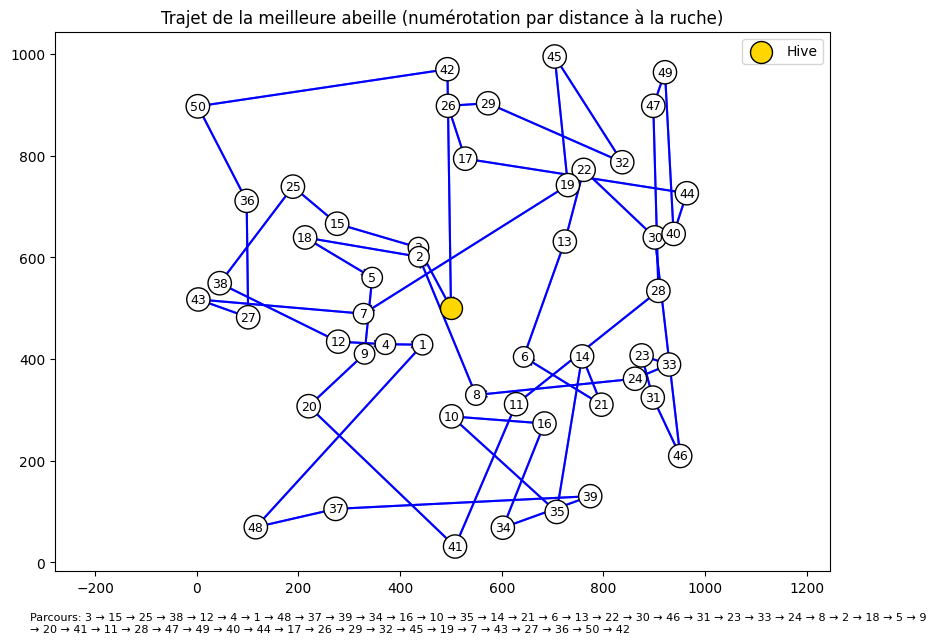

In [33]:

# Création de la ruche et évolution
beehive = Beehive(flowers, hive_position, population_size=101, mutation_rate=0.05, generations=50)
best_bee = beehive.evolve()
#visualisations
plot_best_path(best_bee, hive_position)




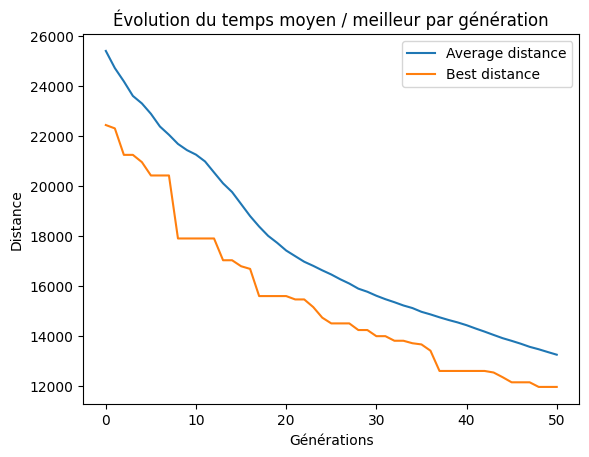

In [34]:
plot_history(beehive)


### Observation : évolution du meilleur chemin
- On observe que la **meilleure distance diminue progressivement** au fil des générations.  
- La **distance moyenne** de la population suit la tendance mais reste plus élevée, montrant que la population conserve de la diversité.  
- Le **meilleur individu** s'améliore régulièrement → preuve que l’algorithme génétique converge.


In [35]:

# Visualisation de la généalogie (10 premières générations + 2 dernières)
#visualize_genealogy(beehive, figsize=(12, 8), save_as=None)



#### Observation : généalogie
- Le graphe montre les **10 premières générations** et les **2 dernières**.  
- La reine est mise en évidence en or, ainsi que la meilleure abeille.  
- Cela illustre comment les individus se transmettent leurs gènes au fil du temps.


### Impact du taux de mutation

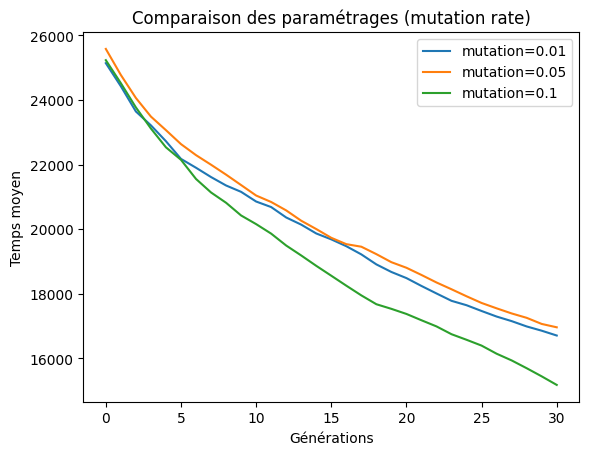

In [36]:

compare_parameters(flowers, hive_position)


#### Observation : taux de mutation
- Un taux trop faible (0.01) → manque de diversité, convergence lente.  
- Un taux trop élevé (0.1) → trop d'aléa, convergence instable.  
- Le meilleur compromis observé est **0.05**, qui équilibre exploration et exploitation.


### Comparaison des metrique de Fitness

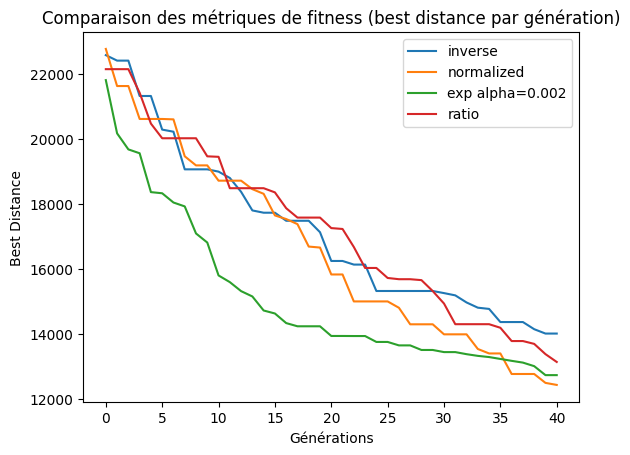

In [37]:

compare_fitness_metrics(flowers, hive_position)



#### Observation : métriques de fitness
- La fitness **exponentielle** (exp) est la plus performante.  
- Les autres méthodes (inverse, normalized, ratio) convergent plus lentement.  
- L’exponentielle augmente la pression sélective et accélère la recherche de solutions.


### Incidence de la methode de selection 

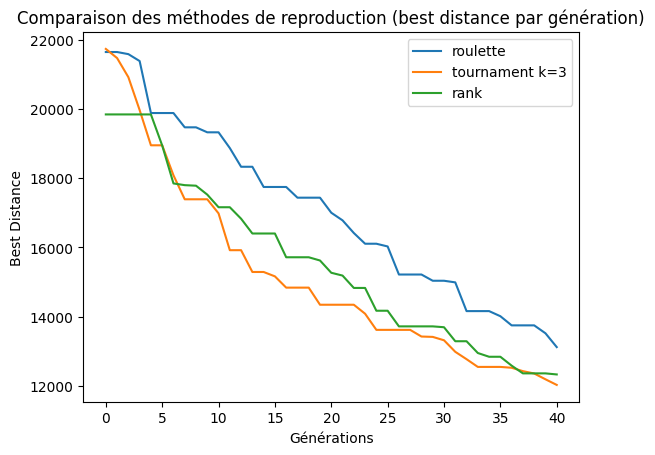

In [38]:
compare_reproduction_methods(flowers, hive_position)



#### Observations :
- **Sélection par rang** est la plus performante → diversité préservée et convergence efficace.  
- **Tournoi** est aussi bon mais légèrement moins rapide.  
- **Roulette** est le moins efficace car trop sensible aux variations de fitness.


### Incidence de la methode de croisement 

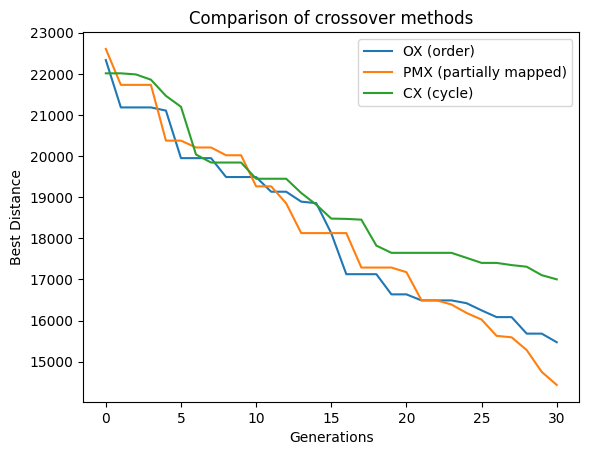

In [39]:

compare_crossover_methods(flowers, hive_position)



#### Observation : 
- **PMX (Partially Mapped Crossover)** est le plus performant.  
- **OX (Order Crossover)** fonctionne bien mais est légèrement moins efficace.  
- **CX (Cycle Crossover)** stagne et donne de moins bons résultats.  



###  Résumé des observations et premières hypothèses

- L’algorithme génétique permet d’optimiser efficacement le trajet des abeilles.  
- Les paramètres influencent fortement les résultats :  
  - **Mutation** : 0.05 est optimal.  
  - **Fitness** : exponentielle est la plus efficace.  
  - **Sélection** : rang > tournoi > roulette.  
  - **Crossover** : PMX > OX > CX.  

En combinant **fitness exponentielle + sélection par rang + crossover PMX + mutation 0.05**,  
on obtient les meilleures performances observées.


### Comparaison des paramètres et recherche de la combinaison optimale

In [28]:
import random, numpy as np, pandas as pd, time
from beehive2 import Beehive

random.seed(42)
np.random.seed(42)

# Chargement des données
flowers = load_flowers_from_csv("C:/Users/ndiay/OneDrive/Desktop/miel_abeille/venv/Champ_fleurs.csv")
hive_position = (500,500)

# Fonction d'évaluation
def run_config(config, runs=5):
    """Exécute plusieurs runs d'une même configuration et renvoie les moyennes."""
    results, times = [], []
    for seed in range(runs):
        random.seed(seed)
        np.random.seed(seed)
        start = time.time()
        hive = Beehive(
            flowers, hive_position,
            population_size=config["pop_size"],
            mutation_rate=config["mutation_rate"],
            fitness_mode=config["fitness_mode"],
            selection_method=config["selection_method"],
            crossover_method=config["crossover_method"],
            generations=config["generations"],
        )
        best = hive.evolve()
        results.append(best.distance)
        times.append(time.time() - start)
    return {
        "mean_best": np.mean(results),
        "std_best": np.std(results),
        "min_best": np.min(results),
        "mean_time": np.mean(times)
    }

# Paramètres à tester
mut_rates = [0.01, 0.05, 0.1]
crossovers = ["pmx", "ox", "cx"]
selections = ["rank", "tournament", "roulette"]

rows = []
for mr in mut_rates:
    for co in crossovers:
        for sel in selections:
            cfg = {
                "pop_size": 101,
                "mutation_rate": mr,
                "fitness_mode": "exp",
                "selection_method": sel,
                "crossover_method": co,
                "generations": 50,
            }
            print(f" Test : mutation={mr}, crossover={co}, selection={sel}")
            summary = run_config(cfg, runs=5)
            rows.append({**cfg, **summary})
            print(" Terminé :", summary)

# Sauvegarde des résultats
df_results = pd.DataFrame(rows)
df_results.to_csv("comparaison_parametres.csv", index=False)
df_results.sort_values("mean_best")


 Test : mutation=0.01, crossover=pmx, selection=rank
 Terminé : {'mean_best': np.float64(12675.318709771644), 'std_best': np.float64(667.2046863158461), 'min_best': np.float64(11730.680181756692), 'mean_time': np.float64(158.42562260627747)}
 Test : mutation=0.01, crossover=pmx, selection=tournament
 Terminé : {'mean_best': np.float64(12145.295563199166), 'std_best': np.float64(596.8263079548839), 'min_best': np.float64(11600.506159492485), 'mean_time': np.float64(3.533586549758911)}
 Test : mutation=0.01, crossover=pmx, selection=roulette
 Terminé : {'mean_best': np.float64(13918.679268462549), 'std_best': np.float64(839.1095285992568), 'min_best': np.float64(12926.641685989114), 'mean_time': np.float64(91.0933310508728)}
 Test : mutation=0.01, crossover=ox, selection=rank
 Terminé : {'mean_best': np.float64(11130.385825522657), 'std_best': np.float64(575.082348889154), 'min_best': np.float64(10102.125850668423), 'mean_time': np.float64(174.0629807472229)}
 Test : mutation=0.01, cross

,pop_size,mutation_rate,fitness_mode,selection_method,crossover_method,generations,mean_best,std_best,min_best,mean_time
13,101,0.05,exp,tournament,ox,50,9969.692932,626.888888,9161.439846,8.707971
23,101,0.10,exp,roulette,ox,50,10231.655340,368.235743,9616.212564,64.254019
4,101,0.01,exp,tournament,ox,50,10420.219529,303.666050,9860.976461,4.499434
22,101,0.10,exp,tournament,ox,50,10649.148002,668.084022,9596.964890,3.871910
12,101,0.05,exp,rank,ox,50,10735.224663,425.539199,9956.723625,285.340885
21,101,0.10,exp,rank,ox,50,10796.735303,369.261276,10402.259277,113.973051
19,101,0.10,exp,tournament,pmx,50,10841.438940,608.250855,9698.432438,2.654337
14,101,0.05,exp,roulette,ox,50,10906.916693,829.114592,9689.029364,120.309316
20,101,0.10,exp,roulette,pmx,50,10948.181876,348.951894,10265.578179,61.619364
3,101,0.01,exp,rank,ox,50,11130.385826,575.082349,10102.125851,174.062981


### Analyse des combinaisons de paramètres (Crossover × Sélection)

Ce graphique compare les **performances moyennes** (distance moyenne parcourue) obtenues par l’algorithme selon différentes **combinaisons** de méthodes de **crossover** (croisement) et de **sélection**.

L’objectif est d’identifier la combinaison qui minimise la **distance moyenne**, c’est-à-dire celle qui permet aux abeilles d’effectuer les **parcours les plus optimisés**.



####  Lecture du graphique
- Chaque barre correspond à une combinaison du type :
méthode de crossover / méthode de sélection

 Configuration optimale observée :
pop_size                    101
mutation_rate              0.05
fitness_mode                exp
selection_method     tournament
crossover_method             ox
generations                  50
mean_best           9969.692932
std_best             626.888888
min_best            9161.439846
mean_time              8.707971
Name: 13, dtype: object


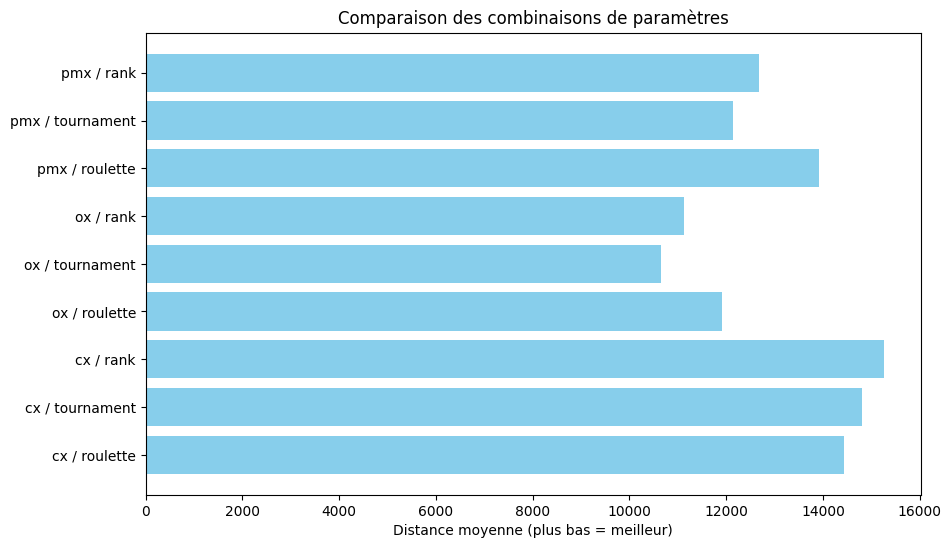

In [42]:
import matplotlib.pyplot as plt

# Tri par performance moyenne
best_cfg = df_results.sort_values("mean_best").iloc[0]
print(" Configuration optimale observée :")
print(best_cfg)

plt.figure(figsize=(10, 6))
plt.barh(df_results["crossover_method"] + " / " + df_results["selection_method"],
          df_results["mean_best"], color="skyblue")
plt.xlabel("Distance moyenne (plus bas = meilleur)")
plt.title("Comparaison des combinaisons de paramètres")
plt.gca().invert_yaxis()
plt.show()


- Plus la barre est **courte**, plus la **distance moyenne est faible** → donc meilleure performance.
- Une barre longue signifie que la méthode est **moins efficace** (chemins plus longs en moyenne).



#### Observations clés

#####  **1. OX / Tournament et OX / Rank → les meilleures combinaisons**
Ces deux combinaisons affichent les **plus faibles distances moyennes**, ce qui signifie qu’elles produisent des solutions plus efficaces.

- **Order Crossover (OX)** conserve l’ordre relatif des gènes, donc la cohérence du parcours.
- Couplé à la **sélection par tournoi** ou **par rang**, cela maintient une **pression sélective équilibrée** :
- les meilleurs individus sont privilégiés,
- tout en gardant une certaine diversité génétique.

 **Résultat :** une convergence rapide et stable vers des parcours courts et cohérents.



####  **2. PMX / Tournament et PMX / Rank → très bonnes performances, mais légèrement inférieures**
Le **Partially Mapped Crossover (PMX)** reste performant et robuste :
- Il préserve les sous-structures locales importantes.
- Cependant, le mécanisme de mapping ralentit légèrement la convergence initiale.

 **Résultat :** une évolution plus douce et plus stable sur le long terme, mais un peu moins rapide que OX dans les premières générations.



#####  **3. CX (Cycle Crossover) → performances plus faibles**
Les combinaisons basées sur **CX** présentent les distances moyennes les plus élevées :
- Trop de diversité introduite.
- Moins bonne exploitation des bons schémas de parcours.
- Convergence plus lente, parfois chaotique.



#### **Synthèse comparative**

| Crossover / Sélection | Performance | Interprétation |
|------------------------|-------------|----------------|
| **OX / Tournament** |  Excellente | Convergence rapide, structure stable |
| **OX / Rank** |  Très bonne | Bon équilibre entre diversité et performance |
| **PMX / Tournament** |  Bonne | Robuste, convergence plus lente |
| **PMX / Rank** |  Correcte | Stabilité, mais moins réactive |
| **CX / (tous)** |  Faible | Trop aléatoire, manque d’exploitation |



###  **Conclusion**
> Sur cet ensemble de tests, les combinaisons **OX / tournament** et **OX / rank** offrent les **meilleures performances globales**.  
>  
> L’**Order Crossover** permet de préserver la logique du parcours des abeilles,  
> tandis que la **sélection structurée** (tournoi ou rang) assure un bon compromis entre **exploration** et **exploitation**.  
>  
> En d’autres termes : ces deux combinaisons permettent aux abeilles d’apprendre **plus vite et plus efficacement** à trouver le chemin optimal .
